In [3]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"zoee1234","key":"8e17006870f4aa4e37e5a60f162cc2eb"}'}

In [4]:
import os
os.makedirs('/root/.kaggle', exist_ok=True)
!cp kaggle.json /root/.kaggle/
!chmod 600 /root/.kaggle/kaggle.json
!pip install kaggle -q

!kaggle datasets download -d crawford/emnist
!unzip -q emnist.zip -d emnist_data
!ls emnist_data

Dataset URL: https://www.kaggle.com/datasets/crawford/emnist
License(s): CC0-1.0
100% 1.24G/1.24G [01:00<00:00, 21.9MB/s]

emnist-balanced-mapping.txt  emnist-digits-test.csv
emnist-balanced-test.csv     emnist-digits-train.csv
emnist-balanced-train.csv    emnist-letters-mapping.txt
emnist-byclass-mapping.txt   emnist-letters-test.csv
emnist-byclass-test.csv      emnist-letters-train.csv
emnist-byclass-train.csv     emnist-mnist-mapping.txt
emnist-bymerge-mapping.txt   emnist-mnist-test.csv
emnist-bymerge-test.csv      emnist-mnist-train.csv
emnist-bymerge-train.csv     emnist_source_files
emnist-digits-mapping.txt


In [5]:
import pandas as pd
import numpy as np

# Load balanced dataset (no header in these CSVs — first column is label, rest are pixels)
train_df = pd.read_csv('emnist_data/emnist-balanced-train.csv', header=None)
test_df = pd.read_csv('emnist_data/emnist-balanced-test.csv', header=None)

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

# First column = label, remaining 784 columns = 28x28 pixel values
print("Unique labels:", sorted(train_df[0].unique()))
print("Number of classes:", train_df[0].nunique())

Train shape: (112800, 785)
Test shape: (18800, 785)
Unique labels: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24), np.int64(25), np.int64(26), np.int64(27), np.int64(28), np.int64(29), np.int64(30), np.int64(31), np.int64(32), np.int64(33), np.int64(34), np.int64(35), np.int64(36), np.int64(37), np.int64(38), np.int64(39), np.int64(40), np.int64(41), np.int64(42), np.int64(43), np.int64(44), np.int64(45), np.int64(46)]
Number of classes: 47


In [6]:
# Load label mapping (label number -> ASCII code)
mapping = {}
with open('emnist_data/emnist-balanced-mapping.txt', 'r') as f:
    for line in f:
        label, ascii_code = line.strip().split()
        mapping[int(label)] = chr(int(ascii_code))

print("Sample mappings:", {k: mapping[k] for k in list(mapping)[:10]})
print("Total mapped classes:", len(mapping))

Sample mappings: {0: '0', 1: '1', 2: '2', 3: '3', 4: '4', 5: '5', 6: '6', 7: '7', 8: '8', 9: '9'}
Total mapped classes: 47


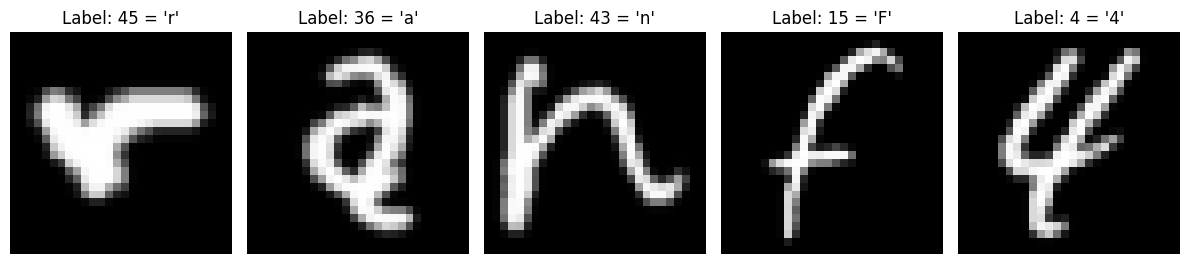

In [7]:
import matplotlib.pyplot as plt

# Visualize a few samples - IMPORTANT: EMNIST images need transpose (rotated/flipped issue)
fig, axes = plt.subplots(1, 5, figsize=(12, 3))

for i in range(5):
    label = train_df.iloc[i, 0]
    pixels = train_df.iloc[i, 1:].values.reshape(28, 28)
    pixels = np.transpose(pixels)  # fix EMNIST rotation quirk

    axes[i].imshow(pixels, cmap='gray')
    axes[i].set_title(f"Label: {label} = '{mapping[label]}'")
    axes[i].axis('off')

plt.tight_layout()
plt.savefig('sample_images.png')
plt.show()

In [8]:
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical

NUM_CLASSES = 47

def preprocess(df):
    labels = df[0].values
    pixels = df.iloc[:, 1:].values.reshape(-1, 28, 28, 1).astype('float32')

    # Apply the same transpose fix to EVERY image
    pixels = np.transpose(pixels, (0, 2, 1, 3))

    # Normalize pixel values from 0-255 to 0-1
    pixels = pixels / 255.0

    return pixels, labels

X_train_full, y_train_full = preprocess(train_df)
X_test, y_test = preprocess(test_df)

# One-hot encode labels for CNN training
y_train_full_cat = to_categorical(y_train_full, NUM_CLASSES)
y_test_cat = to_categorical(y_test, NUM_CLASSES)

# Split a validation set from training data
X_train, X_val, y_train_cat, y_val_cat = train_test_split(
    X_train_full, y_train_full_cat, test_size=0.1, random_state=42
)

print("X_train shape:", X_train.shape)
print("X_val shape:", X_val.shape)
print("X_test shape:", X_test.shape)

X_train shape: (101520, 28, 28, 1)
X_val shape: (11280, 28, 28, 1)
X_test shape: (18800, 28, 28, 1)


In [9]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Flatten, Dropout, BatchNormalization

model = Sequential([
    Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(28,28,1)),
    BatchNormalization(),
    Conv2D(32, (3,3), activation='relu', padding='same'),
    MaxPooling2D((2,2)),
    Dropout(0.25),

    Conv2D(64, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    Conv2D(64, (3,3), activation='relu', padding='same'),
    MaxPooling2D((2,2)),
    Dropout(0.25),

    Flatten(),
    Dense(256, activation='relu'),
    BatchNormalization(),
    Dropout(0.5),
    Dense(NUM_CLASSES, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 28, 28, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       803,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 47)             │        12,079 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 881,551 (3.36 MB)

 Trainable params: 880,847 (3.36 MB)

 Non-trainable params: 704 (2.75 KB)

In [10]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stop = EarlyStopping(
    monitor='val_loss', patience=3, restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6
)

history = model.fit(
    X_train, y_train_cat,
    validation_data=(X_val, y_val_cat),
    epochs=20,
    batch_size=128,
    callbacks=[early_stop, reduce_lr]
)

Epoch 1/20
794/794 ━━━━━━━━━━━━━━━━━━━━ 26s 17ms/step - accuracy: 0.7331 - loss: 0.8876 - val_accuracy: 0.8537 - val_loss: 0.4122 - learning_rate: 0.0010
Epoch 2/20
794/794 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.8414 - loss: 0.4679 - val_accuracy: 0.8708 - val_loss: 0.3550 - learning_rate: 0.0010
Epoch 3/20
794/794 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.8571 - loss: 0.4117 - val_accuracy: 0.8777 - val_loss: 0.3425 - learning_rate: 0.0010
Epoch 4/20
794/794 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.8667 - loss: 0.3825 - val_accuracy: 0.8817 - val_loss: 0.3292 - learning_rate: 0.0010
Epoch 5/20
794/794 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.8719 - loss: 0.3627 - val_accuracy: 0.8809 - val_loss: 0.3199 - learning_rate: 0.0010
Epoch 6/20
794/794 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.8760 - loss: 0.3473 - val_accuracy: 0.8882 - val_loss: 0.3086 - learning_rate: 0.0010
Epoch 7/20
794/794 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.8789 - loss: 0.3

In [12]:
test_loss, test_accuracy = model.evaluate(X_test, y_test_cat)
print(f"Test Accuracy: {test_accuracy*100:.2f}%")
print(f"Test Loss: {test_loss:.4f}")

588/588 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8940 - loss: 0.3050
Test Accuracy: 89.40%
Test Loss: 0.3050


In [13]:
import pickle

# Save trained model
model.save('character_model.h5')

# Save label mapping (needed to convert prediction index back to character)
with open('label_mapping.pkl', 'wb') as f:
    pickle.dump(mapping, f)

print("Model aur mapping save ho gaye ✅")

Model aur mapping save ho gaye ✅


In [14]:
model.save('character_model.keras')